# Preparação das projeções XRMC

Este notebook lê automaticamente as projeções geradas por `runCT_corrigido.py`,
aplica a correção de flat-field e salva **integrais de linha** prontas para o TIGRE.

Parâmetros extraídos dos arquivos XRMC:

- detector: `1024 × 1024`;
- pixel: `0,028 cm = 0,28 mm`;
- fonte: `(0, 0, -100) cm`;
- centro de rotação: `(0, 0, 0)`;
- detector: `(0, 0, 15) cm`;
- `DSO = 1000 mm`;
- `DSD = 1150 mm`.


In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np

DATA_FOLDER = Path(
    "/mnt/d/Iniciacao_cientifica/head_phantom/imagens_raw"
)

OUTPUT_FILE = DATA_FOLDER / "sinoXRMC_corrigido.npz"

# Usado somente para dados antigos sem scan_metadata.json.
FALLBACK_ANGLE_STEP_DEG = 1.0

RAW_DTYPE = np.dtype("float64")
RAW_ROWS = 1024
RAW_COLS = 1024
HEADER_BYTES = 0
EPS = np.float32(1e-6)

print("Pasta:", DATA_FOLDER)


Pasta: /mnt/d/Iniciacao_cientifica/head_phantom/imagens_raw


In [2]:
metadata_path = DATA_FOLDER / "scan_metadata.json"

if metadata_path.is_file():
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    rows, cols = map(int, metadata["nDetector"])
    raw_dtype = np.dtype(metadata.get("raw_dtype", "float64"))
    header_bytes = int(metadata.get("header_bytes", 0))
    angles_deg_meta = np.asarray(metadata["angles_deg"], dtype=np.float32)
else:
    metadata = {}
    rows, cols = RAW_ROWS, RAW_COLS
    raw_dtype = RAW_DTYPE
    header_bytes = HEADER_BYTES
    angles_deg_meta = None
    print(
        "AVISO: scan_metadata.json não foi encontrado. "
        "O passo angular manual será usado."
    )

pattern = re.compile(r"img_(\d{4,})\.dat$")
indexed_files = []

for path in DATA_FOLDER.glob("img_*.dat"):
    match = pattern.fullmatch(path.name)
    if match:
        indexed_files.append((int(match.group(1)), path))

indexed_files.sort()
if not indexed_files:
    raise FileNotFoundError(
        f"Nenhuma projeção img_XXXX.dat encontrada em {DATA_FOLDER}"
    )

indices = [index for index, _ in indexed_files]
expected_indices = list(range(len(indexed_files)))
if indices != expected_indices:
    raise ValueError(
        "A numeração das projeções não é contínua a partir de zero. "
        f"Primeiros índices encontrados: {indices[:20]}"
    )

n_proj = len(indexed_files)

if angles_deg_meta is None:
    angles_deg = (
        np.arange(n_proj, dtype=np.float32)
        * np.float32(FALLBACK_ANGLE_STEP_DEG)
    )
else:
    if angles_deg_meta.size != n_proj:
        raise ValueError(
            f"Metadados: {angles_deg_meta.size} ângulos; "
            f"arquivos: {n_proj} projeções."
        )
    angles_deg = angles_deg_meta

step_deg = (
    float(np.median(np.diff(angles_deg)))
    if n_proj > 1
    else float("nan")
)
coverage_deg = (
    float(angles_deg[-1] - angles_deg[0] + step_deg)
    if n_proj > 1
    else 0.0
)

print("Projeções:", n_proj)
print("Dimensão RAW:", (rows, cols))
print("Passo angular:", step_deg, "grau(s)")
print("Cobertura angular:", coverage_deg, "graus")

if coverage_deg < 350:
    print(
        "ATENÇÃO: a aquisição não cobre aproximadamente 360°. "
        "Para FDK cone-beam, gere uma varredura completa."
    )


AVISO: scan_metadata.json não foi encontrado. O passo angular manual será usado.
Projeções: 360
Dimensão RAW: (1024, 1024)
Passo angular: 1.0 grau(s)
Cobertura angular: 360.0 graus


In [3]:
def read_raw(path: Path) -> np.ndarray:
    expected = rows * cols
    array = np.fromfile(
        path,
        dtype=raw_dtype,
        count=expected,
        offset=header_bytes,
    )
    if array.size != expected:
        raise ValueError(
            f"{path.name}: esperados {expected} valores, "
            f"lidos {array.size}."
        )
    return array.reshape(rows, cols)


flat_path = DATA_FOLDER / metadata.get("flat_file", "flat.dat")
flat = read_raw(flat_path).astype(np.float32)

if not np.isfinite(flat).all():
    raise ValueError("flat.dat contém NaN ou infinito.")
if np.any(flat <= 0):
    raise ValueError("flat.dat contém valores menores ou iguais a zero.")

print(
    "Flat:",
    flat.shape,
    flat.dtype,
    "min =", float(flat.min()),
    "max =", float(flat.max()),
)


Flat: (1024, 1024) float32 min = 9.686772172312877e+21 max = 1.0174048141195482e+22


In [4]:
# Armazena diretamente as integrais de linha no formato TIGRE:
# (projeções, linhas do detector, colunas do detector)
projs_ln = np.empty(
    (n_proj, rows, cols),
    dtype=np.float32,
)

pixels_above_flat = 0
total_pixels = n_proj * rows * cols

for position, (_, path) in enumerate(indexed_files):
    raw = read_raw(path).astype(np.float32)

    transmission = np.divide(
        raw,
        flat,
        out=np.empty_like(raw),
        where=flat > 0,
    )

    pixels_above_flat += int(np.count_nonzero(transmission > 1.0))

    # Valores > 1 surgem por ruído/amostragem Monte Carlo e gerariam
    # integrais de linha negativas. A faixa física é 0 < I/I0 <= 1.
    np.clip(transmission, EPS, 1.0, out=transmission)
    np.log(transmission, out=transmission)
    transmission *= -1.0

    projs_ln[position] = transmission

    if position % max(1, n_proj // 20) == 0:
        print(f"Lidas {position + 1}/{n_proj}")

fraction_above = pixels_above_flat / total_pixels

print("projs_ln:", projs_ln.shape, projs_ln.dtype)
print("Mínimo:", float(projs_ln.min()))
print("Máximo:", float(projs_ln.max()))
print("Média:", float(projs_ln.mean()))
print("Pixels originalmente acima do flat:", f"{fraction_above:.3%}")


Lidas 1/360
Lidas 19/360
Lidas 37/360
Lidas 55/360
Lidas 73/360
Lidas 91/360
Lidas 109/360
Lidas 127/360
Lidas 145/360
Lidas 163/360
Lidas 181/360
Lidas 199/360
Lidas 217/360
Lidas 235/360
Lidas 253/360
Lidas 271/360
Lidas 289/360
Lidas 307/360
Lidas 325/360
Lidas 343/360
projs_ln: (360, 1024, 1024) float32
Mínimo: -0.0
Máximo: 4.368764400482178
Média: 1.5717058181762695
Pixels originalmente acima do flat: 4.908%


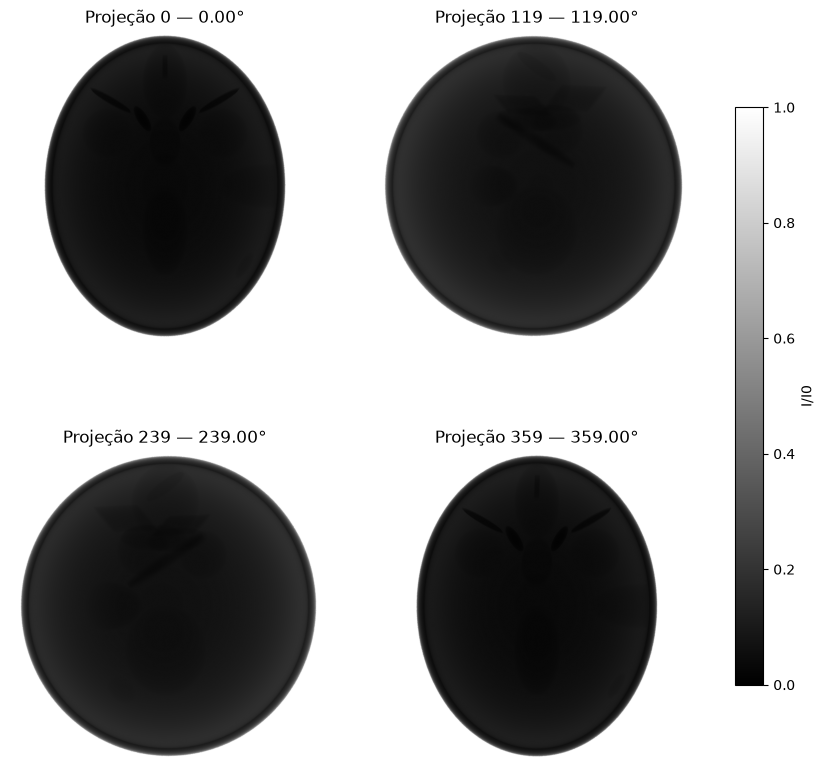

In [5]:
# Visualização de quatro projeções em transmissão
selection = np.linspace(0, n_proj - 1, 4, dtype=int)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for axis, index in zip(axes.ravel(), selection):
    transmission_view = np.exp(-projs_ln[index])
    image = axis.imshow(transmission_view, cmap="gray", vmin=0, vmax=1)
    axis.set_title(
        f"Projeção {index} — {angles_deg[index]:.2f}°"
    )
    axis.axis("off")

fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="I/I0")
plt.show()


In [6]:
# Salva somente float32 e os metadados essenciais.
np.savez_compressed(
    OUTPUT_FILE,
    projs_ln=projs_ln,
    angles_deg=angles_deg.astype(np.float32),
    DSO_mm=np.float32(metadata.get("DSO_mm", 1000.0)),
    DSD_mm=np.float32(metadata.get("DSD_mm", 1150.0)),
    nDetector=np.asarray(
        metadata.get("nDetector", [rows, cols]),
        dtype=np.int32,
    ),
    dDetector_mm=np.asarray(
        metadata.get("dDetector_mm", [0.28, 0.28]),
        dtype=np.float32,
    ),
    rotation_axis_xrmc=np.asarray(
        metadata.get("rotation_axis_xrmc", [0, 1, 0]),
        dtype=np.float32,
    ),
)

print("Arquivo salvo:", OUTPUT_FILE)
print("Tamanho:", OUTPUT_FILE.stat().st_size / 1024**3, "GiB")


Arquivo salvo: /mnt/d/Iniciacao_cientifica/head_phantom/imagens_raw/sinoXRMC_corrigido.npz
Tamanho: 0.8966323863714933 GiB
